In [41]:
### Import All necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.tsa.api as smt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

### Data Preparation and Exploration

In [42]:
### Load the dataset
df=pd.read_csv('exchange_rate.csv')

In [43]:
### Data size
df.shape

(7588, 2)

In [44]:
### Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [45]:
### Stastical Summary
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


* The dataset contains 7,588 exchange rate records.
* The average exchange rate is 0.777.
* The lowest exchange rate is 0.483, and the highest is 1.103.
* Most exchange rate values lie between 0.701 and 0.873.
* The exchange rate varies over time, showing noticeable changes in its values.

In [46]:
### First five rows of data
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [47]:
df.columns

Index(['date', 'Ex_rate'], dtype='object')

In [48]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Set date as index
df.set_index('date', inplace=True)

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


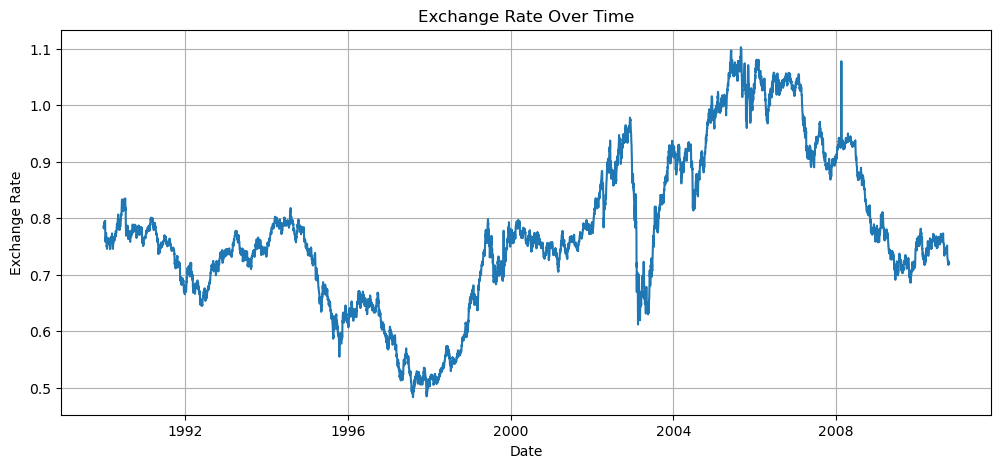

In [49]:
### Initial Exploration 
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Ex_rate'])
plt.title("Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.show()

* The exchange rate goes up and down over the years.
* It decreases from 1990 to around 1998.
* After 1998, the exchange rate increases and reaches its highest value around 2005–2006.
* After that, the exchange rate decreases again.
* A sudden spike can be seen around 2008.
* The graph shows that the exchange rate changes over time and does not remain constant.

<Axes: xlabel='date'>

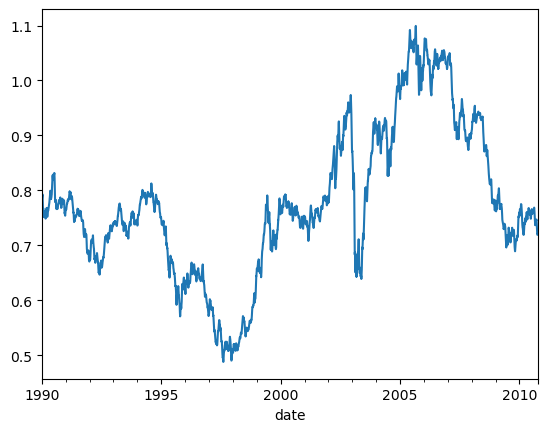

In [50]:
### Seasonality 
result= seasonal_decompose(df['Ex_rate'],model='additive')
result.trend.plot()

* The seasonal component shows repeating changes over time.
* The pattern is not very regular throughout the period.
* There are some periods where the seasonal effect is stronger than others.
* Overall, the seasonal pattern is weak compared to the overall trend.

In [51]:
### Data Preprocessing
# Check Missing vaalues
df.isnull().sum()

Ex_rate    0
dtype: int64

    No Missing values

### Model Building - ARIMA

**Parameter Selection**

In [52]:
def test_stationarity(timeseries):

    #Calculate rolling mean and rolling standard deviation
    rolmean = timeseries.rolling(window = 12).mean()
    rolstd = timeseries.rolling(window = 12).std()

    original = plt.plot(timeseries, color = 'blue', label = 'Original')
    mean = plt.plot(rolmean, color = 'red', label = 'Rolling Mean')
    std = plt.plot(rolstd, color = 'green', label = 'Rolling Std')
    plt.legend(loc='best')


    print('Results of Dickey-Fuller Test :\n')
    df_test = adfuller(timeseries)
    my_output = pd.Series(df_test[0:4], index =['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for i,j in df_test[4].items():
        my_output['Critical Value (%s)'%i] =j
    print(my_output)

Results of Dickey-Fuller Test :

Test Statistic                   -1.664994
p-value                           0.449233
#Lags Used                        1.000000
Number of Observations Used    7586.000000
Critical Value (1%)              -3.431212
Critical Value (5%)              -2.861921
Critical Value (10%)             -2.566973
dtype: float64


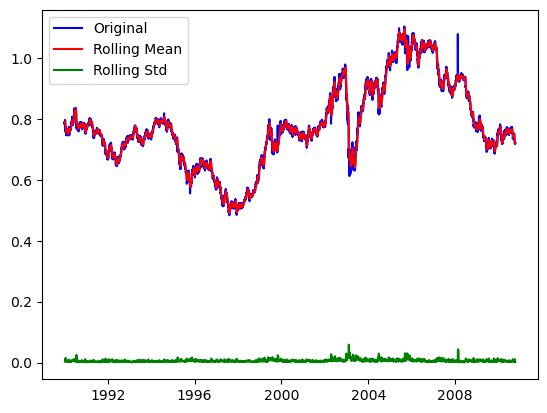

In [53]:
test_stationarity(df['Ex_rate'])

* The p-value is 0.449, which is greater than 0.05.
* This means the exchange rate data is not stationary.
* The ADF test statistic is higher than the critical values, which also indicates that the data is not stationary.
* Since the data is not stationary, differencing is required before building the ARIMA model.

In [54]:
### First ordr differencing
df['Ex_rate_Diff'] = df['Ex_rate'].diff().dropna()

In [55]:
df.head()

,Ex_rate,Ex_rate_Diff
date,,
1990-01-01,0.7855,NaN
1990-01-02,0.7818,-0.0037
1990-01-03,0.7867,0.0049
1990-01-04,0.7860,-0.0007
1990-01-05,0.7849,-0.0011


In [56]:
 ### Drop first row since the diff is zero (previous data is not present so diff is not calculated for 1st row) 
df.dropna(inplace=True)

In [57]:
df.head()

,Ex_rate,Ex_rate_Diff
date,,
1990-01-02,0.7818,-0.0037
1990-01-03,0.7867,0.0049
1990-01-04,0.7860,-0.0007
1990-01-05,0.7849,-0.0011
1990-01-06,0.7866,0.0017


Results of Dickey-Fuller Test :

Test Statistic                  -99.393431
p-value                           0.000000
#Lags Used                        0.000000
Number of Observations Used    7586.000000
Critical Value (1%)              -3.431212
Critical Value (5%)              -2.861921
Critical Value (10%)             -2.566973
dtype: float64


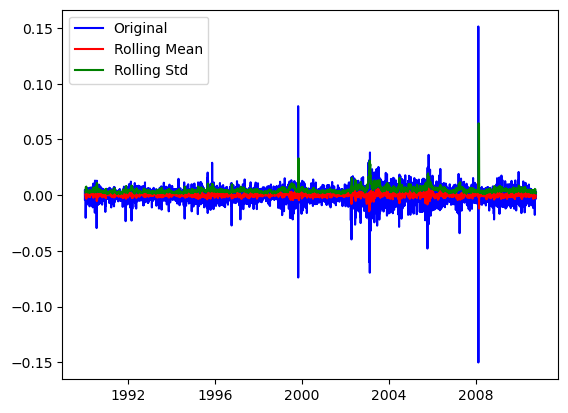

In [58]:
test_stationarity(df['Ex_rate_Diff'])

* The ADF test statistic is -99.3934.
* The p-value is 0.0000, which is less than 0.05.
* This shows that the differenced exchange rate data is stationary.
* The data is now suitable for building the ARIMA model.

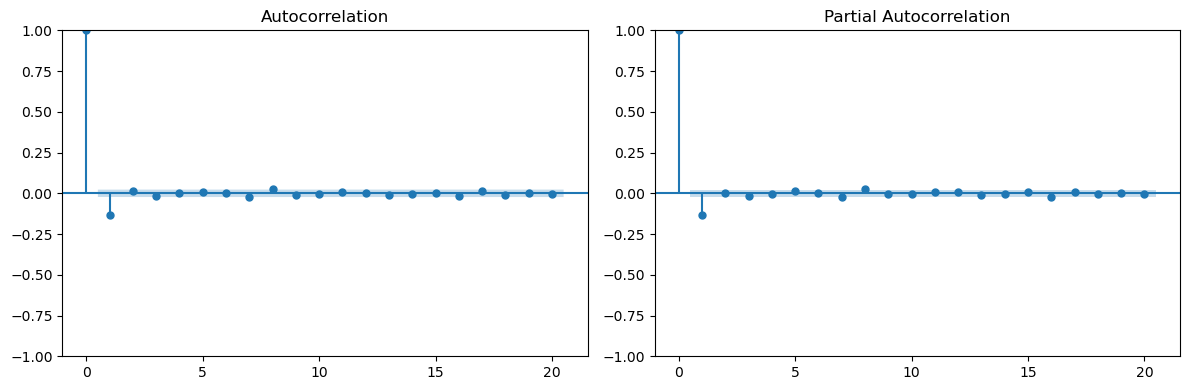

In [59]:
### ACF and PACF plots 
fig, axes = plt.subplots(1, 2)
fig.set_figwidth(12)
fig.set_figheight(4)
smt.graphics.plot_acf(df['Ex_rate_Diff'], lags=20, ax=axes[0])
smt.graphics.plot_pacf(df['Ex_rate_Diff'], lags=20, ax=axes[1])
plt.tight_layout()

* The ACF plot shows a significant spike at lag 1. (p)
* The PACF plot also shows a significant spike at lag 1. (q)
* After lag 1, most values are within the confidence limits.
* Therefore, ARIMA(1,1,1) is chosen as the initial model. (p,d,q)

In [60]:
model = ARIMA(df['Ex_rate'], order=(1,1,1))

In [61]:
result= model.fit()
result.predict()

1990-01-02    0.000000
1990-01-03    0.781800
1990-01-04    0.786056
1990-01-05    0.786089
1990-01-06    0.785045
                ...   
2010-10-06    0.718837
2010-10-07    0.718522
2010-10-08    0.721400
2010-10-09    0.723017
2010-10-10    0.721136
Freq: D, Name: predicted_mean, Length: 7587, dtype: float64

In [62]:
df['predicted']=result.predict()

In [63]:
df.head()

,Ex_rate,Ex_rate_Diff,predicted
date,,,
1990-01-02,0.7818,-0.0037,0.000000
1990-01-03,0.7867,0.0049,0.781800
1990-01-04,0.7860,-0.0007,0.786056
1990-01-05,0.7849,-0.0011,0.786089
1990-01-06,0.7866,0.0017,0.785045


* The predicted values are very close to the actual exchange rates.
* The first predicted value is 0 because the model needs previous observations to make the first prediction.
* From the second observation onwards, the predicted values closely follow the actual values.

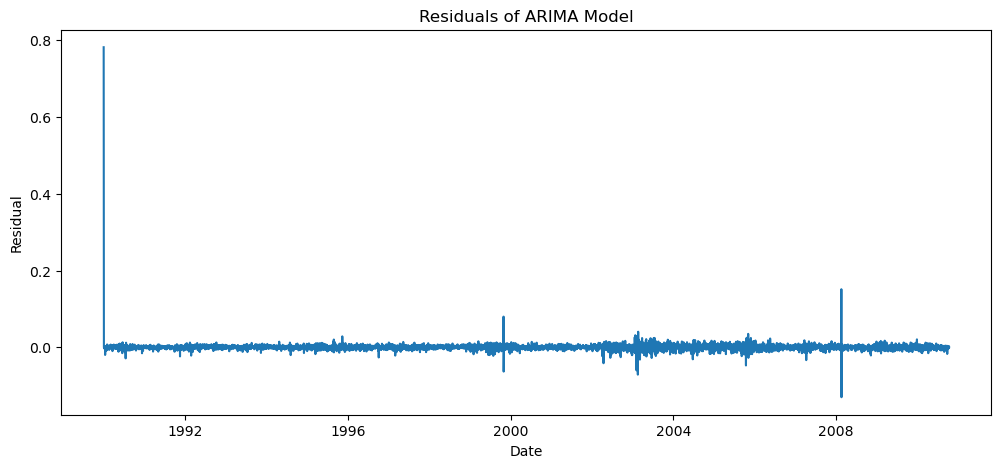

In [64]:
### Diagnostics (Residual Analysis)
residuals = result.resid

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("Residuals of ARIMA Model")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

* The residuals are mostly scattered around zero.
* There is no clear trend or repeating pattern in the residuals.
* A few large spikes are present, indicating some unusual changes that the model could not capture.
* Overall, the residuals appear random, which suggests that the ARIMA model fits the data reasonably well.

In [65]:
### Forcasting for next 60 days
forecast=result.forecast(60)
forecast

2010-10-11    0.720826
2010-10-12    0.720826
2010-10-13    0.720826
2010-10-14    0.720826
2010-10-15    0.720826
2010-10-16    0.720826
2010-10-17    0.720826
2010-10-18    0.720826
2010-10-19    0.720826
2010-10-20    0.720826
2010-10-21    0.720826
2010-10-22    0.720826
2010-10-23    0.720826
2010-10-24    0.720826
2010-10-25    0.720826
2010-10-26    0.720826
2010-10-27    0.720826
2010-10-28    0.720826
2010-10-29    0.720826
2010-10-30    0.720826
2010-10-31    0.720826
2010-11-01    0.720826
2010-11-02    0.720826
2010-11-03    0.720826
2010-11-04    0.720826
2010-11-05    0.720826
2010-11-06    0.720826
2010-11-07    0.720826
2010-11-08    0.720826
2010-11-09    0.720826
2010-11-10    0.720826
2010-11-11    0.720826
2010-11-12    0.720826
2010-11-13    0.720826
2010-11-14    0.720826
2010-11-15    0.720826
2010-11-16    0.720826
2010-11-17    0.720826
2010-11-18    0.720826
2010-11-19    0.720826
2010-11-20    0.720826
2010-11-21    0.720826
2010-11-22    0.720826
2010-11-23 

* The model predicts that the exchange rate will remain almost constant in the coming days.
* There is very little change in the forecasted values.
* This indicates that the model expects the exchange rate to stay stable over the forecast period.

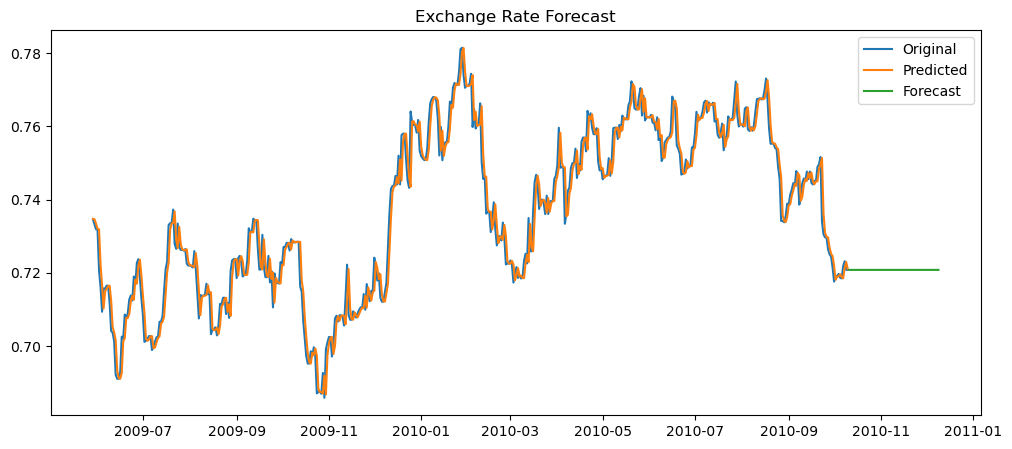

In [66]:
plt.figure(figsize=(12,5))
 ### last 500 observations 
plt.plot(df['Ex_rate'][-500:], label='Original')
plt.plot(df['predicted'][-500:], label='Predicted')
plt.plot(forecast, label='Forecast')

plt.title("Exchange Rate Forecast")
plt.legend()
plt.show()

* The predicted values closely match the original exchange rate values.
* The model follows the overall trend of the exchange rate well.
* The forecast shows that the exchange rate is expected to remain almost stable in the next few days.
* Overall, the ARIMA model provides a good fit to the historical data and predicts a steady future trend.

### Exponential Smoothing Model

In [67]:
### Train-Test Split
train = df['Ex_rate'][:-30]
test = df['Ex_rate'][-30:]

In [68]:
arima_model = ARIMA(train, order=(1,1,1))
arima_fit = arima_model.fit()

In [69]:
arima_forecast = arima_fit.forecast(steps=len(test))

In [70]:
exp_model = ExponentialSmoothing(train, trend='add', seasonal=None)
exp_fit = exp_model.fit()

In [71]:
exp_forecast = exp_fit.forecast(steps=len(test))

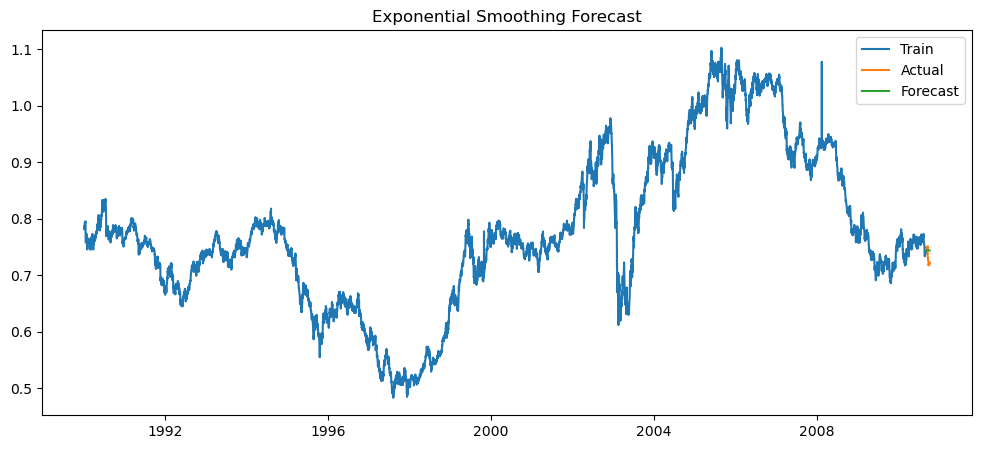

In [72]:
plt.figure(figsize=(12,5))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(exp_forecast, label='Forecast')
plt.title("Exponential Smoothing Forecast")
plt.legend()
plt.show()

### Evaluation and Comparison

In [73]:
### Compute Error Metrics

# ARIMA
mae_arima = mean_absolute_error(test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test, arima_forecast))
mape_arima = np.mean(np.abs((test - arima_forecast) / test)) * 100

# Exponential Smoothing
mae_exp = mean_absolute_error(test, exp_forecast)
rmse_exp = np.sqrt(mean_squared_error(test, exp_forecast))
mape_exp = np.mean(np.abs((test - exp_forecast) / test)) * 100

In [75]:
### Model Comparison
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [mae_arima, mae_exp],
    'RMSE': [rmse_arima, rmse_exp],
    'MAPE': [mape_arima, mape_exp]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.013495,0.016632,1.863224
1,Exponential Smoothing,0.013427,0.016502,1.853671


* Both models produced low error values, indicating good forecasting performance.
* Exponential Smoothing has slightly lower MAE, RMSE, and MAPE than ARIMA.
* This means Exponential Smoothing predicted the exchange rates a little more accurately.

**Conclusion**
* Both ARIMA and Exponential Smoothing models were successfully used to forecast the exchange rates.
* The models were evaluated using MAE, RMSE, and MAPE, and both achieved low error values, indicating good forecasting performance.
* Exponential Smoothing performed slightly better than ARIMA, with lower MAE (0.013427), RMSE (0.016502), and MAPE (1.853671).
* Based on these results, Exponential Smoothing yielded the best performance for forecasting exchange rates in this dataset.
* Overall, both models produced reliable forecasts, but Exponential Smoothing was the more accurate model for this analysis.